In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [3]:
X_train = pd.read_pickle('../datos/entrenamiento/X_train.pkl')
X_test = pd.read_pickle('../datos/entrenamiento/X_test.pkl')
y_train = pd.read_pickle('../datos/entrenamiento/y_train.pkl')
y_test = pd.read_pickle('../datos/entrenamiento/y_test.pkl')


In [4]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22721 entries, 25579 to 16841
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   ingreso                               22721 non-null  float64
 1   duracion_empleo                       22721 non-null  float64
 2   tasa_interes                          22721 non-null  float64
 3   porcentaje_ingreso                    22721 non-null  float64
 4   duracion_credito                      22721 non-null  float64
 5   propiedad_vivienda_OWN                22721 non-null  float64
 6   propiedad_vivienda_RENT               22721 non-null  float64
 7   intencion_prestamo_DEBTCONSOLIDATION  22721 non-null  float64
 8   intencion_prestamo_HOMEIMPROVEMENT    22721 non-null  float64
 9   intencion_prestamo_MEDICAL            22721 non-null  float64
 10  intencion_prestamo_VENTURE            22721 non-null  float64
dtypes: float64(11)
m

In [5]:
rl = LogisticRegression(max_iter=1000,class_weight='balanced' ,random_state=42, solver='saga')

param_grid = [
    # Sin penalización
    {
        'penalty': [None,'l2'],
        'solver': ['lbfgs']
    },
    # Con penalización L1 y L2
    {
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'solver': ['saga']
    }
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [6]:
grid_search = GridSearchCV(estimator=rl,
                           param_grid=param_grid,
                           cv=skf,
                           scoring='roc_auc',
                           n_jobs=-1)

In [7]:
mejor_modelo = grid_search.fit(X_train,y_train)
print('Mejor combinación:' , grid_search.best_params_)

#Toda la tabla
pd.DataFrame(grid_search.cv_results_)[['params', 'mean_test_score']].sort_values('mean_test_score', ascending = False)

Mejor combinación: {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}


,params,mean_test_score
6,"{'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}",0.860641
8,"{'C': 1.0, 'penalty': 'l1', 'solver': 'saga'}",0.860536
0,"{'penalty': None, 'solver': 'lbfgs'}",0.860531
13,"{'C': 100.0, 'penalty': 'l2', 'solver': 'saga'}",0.860526
10,"{'C': 10.0, 'penalty': 'l1', 'solver': 'saga'}",0.860525
12,"{'C': 100.0, 'penalty': 'l1', 'solver': 'saga'}",0.860525
11,"{'C': 10.0, 'penalty': 'l2', 'solver': 'saga'}",0.860517
9,"{'C': 1.0, 'penalty': 'l2', 'solver': 'saga'}",0.860505
1,"{'penalty': 'l2', 'solver': 'lbfgs'}",0.860501
7,"{'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}",0.859190


In [8]:
from sklearn.model_selection import cross_val_score


rl2 = LogisticRegression(max_iter=1000, solver='saga', penalty='l2', C=1.0)

rl2.fit(X_train, y_train)

X_test_pred = rl2.predict_proba(X_test)[:, 1]

metricas_cv = cross_val_score(
    estimator=rl2, 
    X=X_train, 
    y=y_train, 
    cv=skf, 
    scoring='roc_auc',
    n_jobs=-1
)

# 4. Ver resultados
print(f"ROC AUC Folds: {metricas_cv}")
print(f"ROC AUC Score Promedio (Cross-Validation): {metricas_cv.mean():.4f}")


ROC AUC Folds: [0.86576129 0.85824705 0.8640643  0.86450366 0.84770918]
ROC AUC Score Promedio (Cross-Validation): 0.8601


c:\Users\valen\miniconda3\envs\prediccion-riesgo-credito\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


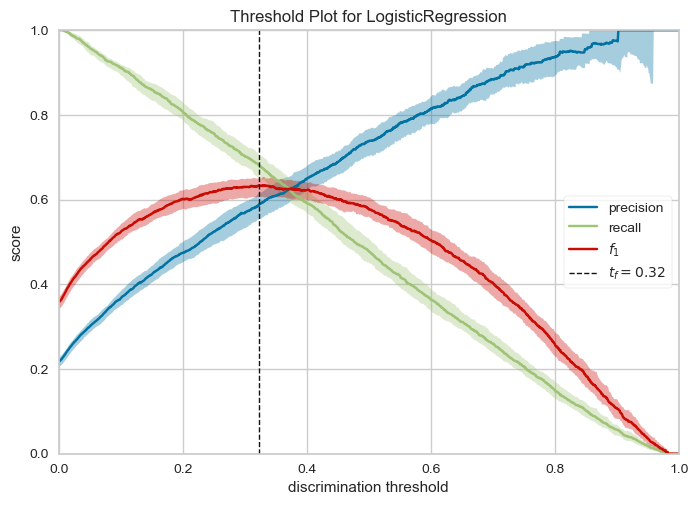

In [9]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from yellowbrick.classifier import discrimination_threshold

discrimination_threshold(rl2, X_train, y_train, exclude='queue_rate')
plt.show()